In [1]:

from langgraph.graph import  StateGraph, START, END
from typing import TypedDict
from dotenv import  load_dotenv
from langgraph.checkpoint.memory import  InMemorySaver
from langchain_openai import ChatOpenAI

/Users/rahulprajapati/miniconda3/envs/langchain/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()

True

In [10]:
model = ChatOpenAI(model = 'gpt-4o')

In [11]:
# define the state

class JokeState(TypedDict):
    topic: str
    joke: str
    explaination: str

In [12]:
def generate_joke(state: JokeState):

    prompt = f"generate the joke on given topic - \n {state['topic']}"

    response = model.invoke(prompt).content

    return {'joke': response}


def generate_exaplaination(state: JokeState):

    prompt = f"write a explaination on given joke - \n {state['joke']}"

    response = model.invoke(prompt).content

    return {'explaination': response}

In [13]:
# define the StateGraph

graph = StateGraph(JokeState)

# add node
graph.add_node('generate_joke',generate_joke)

graph.add_node('generate_exaplaination',generate_exaplaination)

# add edge
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_exaplaination')
graph.add_edge('generate_exaplaination', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

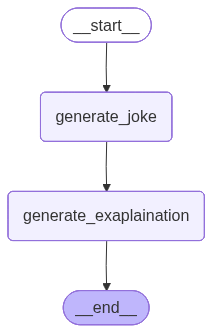

In [14]:
graph.compile()

In [15]:
config_1 = {'configurable': {'thread_id': "1"}}

initial_state = {'topic': 'pizza'}

final_state = workflow.invoke(initial_state, config=config_1)

final_state

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕',
 'explaination': 'This joke is a classic example of a pun, which is a form of wordplay that exploits the multiple meanings of a word or phrase for a humorous effect. \n\nIn this joke, the punchline revolves around the word "dough." In the context of pizza making, "dough" refers to the uncooked, leavened mixture of flour, water, and yeast that forms the base of a pizza. However, "dough" is also a slang term for money.\n\nThe humor arises from the dual meanings of "dough." The setup of the joke, "Why did the pizza maker go broke?" implies that there is a financial issue at play. The punchline, "Because he just couldn’t make enough dough!" is funny because it can be interpreted in two ways:\n\n1. The pizza maker couldn\'t produce enough pizza dough to sustain his business, which humorously results in financial ruin.\n2. The pizza maker couldn\'t earn enough money (dough), lead

In [16]:
workflow.get_state(config_1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕', 'explaination': 'This joke is a classic example of a pun, which is a form of wordplay that exploits the multiple meanings of a word or phrase for a humorous effect. \n\nIn this joke, the punchline revolves around the word "dough." In the context of pizza making, "dough" refers to the uncooked, leavened mixture of flour, water, and yeast that forms the base of a pizza. However, "dough" is also a slang term for money.\n\nThe humor arises from the dual meanings of "dough." The setup of the joke, "Why did the pizza maker go broke?" implies that there is a financial issue at play. The punchline, "Because he just couldn’t make enough dough!" is funny because it can be interpreted in two ways:\n\n1. The pizza maker couldn\'t produce enough pizza dough to sustain his business, which humorously results in financial ruin.\n2. The pizza maker couldn\'t earn enough 

In [18]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕', 'explaination': 'This joke is a classic example of a pun, which is a form of wordplay that exploits the multiple meanings of a word or phrase for a humorous effect. \n\nIn this joke, the punchline revolves around the word "dough." In the context of pizza making, "dough" refers to the uncooked, leavened mixture of flour, water, and yeast that forms the base of a pizza. However, "dough" is also a slang term for money.\n\nThe humor arises from the dual meanings of "dough." The setup of the joke, "Why did the pizza maker go broke?" implies that there is a financial issue at play. The punchline, "Because he just couldn’t make enough dough!" is funny because it can be interpreted in two ways:\n\n1. The pizza maker couldn\'t produce enough pizza dough to sustain his business, which humorously results in financial ruin.\n2. The pizza maker couldn\'t earn enough

In [19]:
config_2 = {'configurable': {'thread_id': "2"}}

initial_state = {'topic': 'pasta'}

final_state = workflow.invoke(initial_state, config=config_2)

final_state

{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the penne?\n\nBecause it just couldn\'t handle the "impasta"!',
 'explaination': 'This joke plays on the word "impasta," a pun derived from "imposter." Here\'s a breakdown of the humor:\n\n1. **Setup**: The joke sets up a scenario involving two types of pasta—spaghetti and penne—and mentions a breakup, which anthropomorphizes the pasta, implying they are in a relationship.\n\n2. **Pun**: The punchline hinges on the word "impasta," which sounds similar to "imposter." The idea is that spaghetti broke up with penne because it couldn\'t handle feeling deceived or because it didn\'t see penne as genuine.\n\n3. **Humor**: The humor arises from the silliness of pasta having romantic relationships and the clever wordplay. Since "impasta" is not a real word, the absurdity of imagining pasta with feelings is light-hearted and amusing.\n\nOverall, the joke is amusing because it combines everyday food items with a play on words to cr

### Time Travel

In [ ]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f156a18-a71f-601e-8001-fcb682e3675f"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': "1f156a18-a71f-601e-8001-fcb682e3675f'"}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [21]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f156a18-a71f-601e-8001-fcb682e3675f"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕',
 'explaination': 'This joke is a play on words, or a pun, that relies on the double meaning of the word "dough." In the context of pizza making, "dough" refers to the uncooked, thick, malleable mixture that forms the base of a pizza. For a pizza maker, making dough is a literal part of their job, as they need it to create pizzas.\n\nHowever, "dough" is also a slang term for money. When we say someone couldn\'t "make enough dough," it commonly means they aren\'t earning enough money. \n\nThe humor in the joke comes from combining these two meanings: the pizza maker went broke because he couldn\'t make enough "dough," meaning he both failed to produce enough pizza (literally) and failed to earn enough money (figuratively). The pun ties together the act of making pizza and the concept of financial success, creating an amusing connection between the two. The light-heartedness o

In [23]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕', 'explaination': 'This joke is a play on words, or a pun, that relies on the double meaning of the word "dough." In the context of pizza making, "dough" refers to the uncooked, thick, malleable mixture that forms the base of a pizza. For a pizza maker, making dough is a literal part of their job, as they need it to create pizzas.\n\nHowever, "dough" is also a slang term for money. When we say someone couldn\'t "make enough dough," it commonly means they aren\'t earning enough money. \n\nThe humor in the joke comes from combining these two meanings: the pizza maker went broke because he couldn\'t make enough "dough," meaning he both failed to produce enough pizza (literally) and failed to earn enough money (figuratively). The pun ties together the act of making pizza and the concept of financial success, creating an amusing connection between the two. The

### Updating State

In [24]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f156a18-99f9-6a42-bfff-53b8f7989016", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f156a4c-366f-6902-8000-b6e043e4f3a2'}}

In [26]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a4c-366f-6902-8000-b6e043e4f3a2'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-05-23T12:41:47.812664+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a18-99f9-6a42-bfff-53b8f7989016'}}, tasks=(PregelTask(id='6fd771cf-674b-1f2a-2985-e8425934830b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough! 🍕', 'explaination': 'This joke is a play on words, or a pun, that relies on the double meaning of the word "dough." In the context of pizza making, "dough" refers to the uncooked, thick, malleable mixture that forms the base of a pizza. For a pizza 